
# DeepONet + 1D Poisson + Laplace Approximation

This notebook builds a **1D scientific machine learning** example around a steady Poisson boundary-value problem and then adds **Laplace uncertainty quantification** on top of a trained DeepONet surrogate.

We solve

$$
-u''(x) = f(x), \qquad x \in [0,1], \qquad u(0)=u(1)=0,
$$

and learn the operator

$$
\mathcal{G}: f(x) \mapsto u(x).
$$

The notebook has three goals:

1. train a DeepONet that reaches **very small field error** on the in-domain test set,
2. use Laplace approximation without changing the existing Deep-UQ API,
3. show that uncertainty is **higher in the spatial region where the input forcing field is poorly observed**.



## Physical meaning

This is a steady-state diffusion / elasticity / potential problem.

Depending on the interpretation:

- $u(x)$ can be **temperature**, **displacement**, or **electric potential**,
- $f(x)$ is the **source term**, **distributed load**, or **charge density**.

So the scientific task is:

- observe a 1D source field $f(x)$ at a limited set of sensor locations,
- infer the full equilibrium response field $u(x)$,
- quantify how uncertain the learned surrogate is along the 1D domain.

That makes this a natural operator-learning problem with a clear physical meaning.



## Why uncertainty should be spatially structured here

A standard operator-learning example with full dense input data at every $x$ would not naturally produce a strong **spatial** uncertainty pattern.

To make the 1D uncertainty story more meaningful, this notebook uses a **nonuniform sensor layout** for the input forcing field:

- dense sensors near the left part of the domain,
- dense sensors near the right part of the domain,
- a clear **sensor gap in the middle**.

That means the model has less information about the forcing field in the middle region, so a good uncertainty method should become less confident there.



## Training strategy

A plain DeepONet can learn this operator, but we can do much better with a more logical training design.

We use a **hybrid residual strategy**:

1. Build a deterministic physics baseline by:
   - interpolating the sparse forcing measurements onto the fine grid,
   - solving the Poisson problem for that interpolated forcing.
2. Train DeepONet only on the **correction residual** between that baseline solution and the true solution.

This is a good scientific ML design because:

- the known PDE structure is already doing most of the easy work,
- the learned model only corrects what sparse sensing and interpolation get wrong,
- the residual is much smaller than the full solution field,
- Laplace can then quantify uncertainty in the learned correction.

This is why the notebook can reach very low RMSE while still leaving room for meaningful uncertainty.


In [46]:
# Notebook bootstrap
# - Force imports to resolve to the local repo in `src/`.
# - This avoids accidentally importing an older installed version of deepuq.

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent if PROJECT_ROOT.name == 'sciml' else PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)


In [47]:
# Core imports and reproducibility

import copy
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LaplaceWrapper
from deepuq.models import DeepONet1D

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda



## Configuration

Two modes are provided:

- `USE_QUICK_CONFIG = True`: a smaller run for smoke testing,
- `USE_QUICK_CONFIG = False`: the fuller tutorial configuration.

The default full setting is tuned to reach **test RMSE at or below 0.001** while still keeping the notebook CPU-friendly.


In [48]:
# Configuration block
# - These settings control the data difficulty, model size, and optimization budget.
# - The full configuration is tuned for a strong in-domain fit and a visible spatial UQ pattern.
# - The key modeling knob is the nonuniform sensor layout: it creates the middle region with weaker information.

# Experiment configuration

USE_QUICK_CONFIG = False

@dataclass
class ExperimentConfig:
    sensor_left_end: float = 0.38
    sensor_right_start: float = 0.62
    n_left_sensors: int = 14
    n_right_sensors: int = 14
    query_resolution: int = 129
    n_train: int = 500
    n_val: int = 100
    n_test: int = 100
    n_ood: int = 100
    batch_size: int = 32
    lr: float = 1e-3
    max_lr: float = 3e-3
    weight_decay: float = 1e-5
    epochs: int = 260
    min_epochs: int = 80
    patience: int = 40
    early_stopping_min_delta: float = 1e-6
    use_early_stopping: bool = True
    grad_clip: float = 1.0
    latent_dim: int = 160
    hidden_dim: int = 160
    depth: int = 4
    train_max_mode: int = 4
    ood_max_mode: int = 10
    train_amplitude: float = 1.0
    ood_amplitude: float = 1.7
    compare_kron: bool = False
    laplace_prior_precision: float = 150.0
    laplace_samples: int = 64

if USE_QUICK_CONFIG:
    config = ExperimentConfig(
        n_train=180,
        n_val=40,
        n_test=40,
        n_ood=40,
        epochs=140,
        min_epochs=40,
        patience=24,
        latent_dim=112,
        hidden_dim=112,
        query_resolution=97,
    )
else:
    config = ExperimentConfig()

config


ExperimentConfig(sensor_left_end=0.38, sensor_right_start=0.62, n_left_sensors=14, n_right_sensors=14, query_resolution=129, n_train=500, n_val=100, n_test=100, n_ood=100, batch_size=32, lr=0.001, max_lr=0.003, weight_decay=1e-05, epochs=260, min_epochs=80, patience=40, early_stopping_min_delta=1e-06, use_early_stopping=True, grad_clip=1.0, latent_dim=160, hidden_dim=160, depth=4, train_max_mode=4, ood_max_mode=10, train_amplitude=1.0, ood_amplitude=1.7, compare_kron=False, laplace_prior_precision=150.0, laplace_samples=64)

### How to use the configuration

A new reader usually only needs to change three things:

- `USE_QUICK_CONFIG`: switch between a fast demo run and the fuller tutorial run,
- `ood_max_mode` / `ood_amplitude`: make the OOD shift milder or harsher,
- `compare_kron`: turn on the optional Laplace backend comparison.

The sensor-gap geometry is the most important scientific choice in this notebook, because it creates the spatial region where uncertainty should increase.


## Neural-operator input and output

For each sample in this notebook:

- **input field**: one source / forcing field $f(x)$ measured at the sensor locations,
- **output field**: one equilibrium response field $u(x)$ on the fine query grid.

So this is a **field-to-field neural operator**:

$$
\mathcal{G}: f(x) \mapsto u(x).
$$

Tensor shapes in this notebook:

- branch input: `[batch, n_sensor_points]`
- output field: `[batch, n_query_points]`



## Dataset generation

We sample forcing fields from a sine basis:

$$
f(x) = \sum_{k=1}^{K} a_k \sin(k \pi x),
$$

with random coefficients $a_k$.

Why this is useful:

- it gives smooth physically plausible fields,
- the training set stays low-frequency,
- OOD samples can be created by increasing both the **frequency content** and the **amplitude**.

The true response is computed by solving the Poisson equation on a fine grid with zero Dirichlet boundary conditions.


In [49]:
# PDE, interpolation, and dataset helpers
# - `make_sensor_grid` creates the intentionally nonuniform sensor layout.
# - `make_poisson_dataset` builds three objects for each sample:
#     1) sparse forcing observations on the sensor grid,
#     2) the true forcing and true Poisson solution on the fine grid,
#     3) a baseline solution computed from interpolated sensor data.
# - That baseline is important because the network only has to learn the correction on top of it.

# PDE, interpolation, and dataset helpers


def make_query_grid(n_points: int) -> torch.Tensor:
    return torch.linspace(0.0, 1.0, n_points).float()


def make_sensor_grid(cfg: ExperimentConfig) -> torch.Tensor:
    left = torch.linspace(0.0, cfg.sensor_left_end, cfg.n_left_sensors)
    right = torch.linspace(cfg.sensor_right_start, 1.0, cfg.n_right_sensors)
    return torch.unique(torch.cat([left, right])).float()


def sample_forcing_coefficients(
    n_samples: int,
    max_mode: int,
    amplitude_scale: float,
    *,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    modes = torch.arange(1, max_mode + 1, dtype=torch.float32)
    decay = modes.pow(-1.6)
    coeffs = torch.randn(n_samples, max_mode, generator=generator)
    return amplitude_scale * coeffs * decay.unsqueeze(0)


def evaluate_sine_series(coefficients: torch.Tensor, x_grid: torch.Tensor) -> torch.Tensor:
    modes = torch.arange(1, coefficients.size(1) + 1, dtype=coefficients.dtype)
    basis = torch.sin(math.pi * modes[:, None] * x_grid[None, :])
    return coefficients @ basis


def build_poisson_matrix(n_points: int, *, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    interior = n_points - 2
    h = 1.0 / (n_points - 1)
    main = 2.0 * torch.ones(interior, dtype=dtype)
    off = -1.0 * torch.ones(interior - 1, dtype=dtype)
    matrix = torch.diag(main) + torch.diag(off, diagonal=1) + torch.diag(off, diagonal=-1)
    return matrix / (h ** 2)


def solve_poisson_dirichlet_batch(forcing: torch.Tensor) -> torch.Tensor:
    if forcing.dim() != 2:
        raise ValueError('forcing must have shape [batch, n_points].')
    n_points = forcing.size(1)
    stiffness = build_poisson_matrix(n_points, dtype=forcing.dtype).to(forcing)
    rhs = forcing[:, 1:-1]
    u_interior = torch.linalg.solve(stiffness, rhs.T).T
    solution = torch.zeros_like(forcing)
    solution[:, 1:-1] = u_interior
    return solution


def interpolate_sensor_values(
    sensor_grid: torch.Tensor,
    sensor_values: torch.Tensor,
    query_grid: torch.Tensor,
) -> torch.Tensor:
    # Batched piecewise-linear interpolation from the sparse sensor grid to the fine query grid.
    idx = torch.searchsorted(sensor_grid, query_grid, right=True)
    idx = idx.clamp(1, sensor_grid.numel() - 1)

    x0 = sensor_grid[idx - 1]
    x1 = sensor_grid[idx]
    weight = ((query_grid - x0) / (x1 - x0).clamp_min(1e-12)).unsqueeze(0)

    y0 = sensor_values[:, idx - 1]
    y1 = sensor_values[:, idx]
    out = y0 + (y1 - y0) * weight
    out[:, 0] = sensor_values[:, 0]
    out[:, -1] = sensor_values[:, -1]
    return out


def make_poisson_dataset(
    n_samples: int,
    *,
    sensor_grid: torch.Tensor,
    query_grid: torch.Tensor,
    max_mode: int,
    amplitude_scale: float,
    seed: int,
):
    generator = torch.Generator().manual_seed(seed)
    coeffs = sample_forcing_coefficients(
        n_samples=n_samples,
        max_mode=max_mode,
        amplitude_scale=amplitude_scale,
        generator=generator,
    )
    forcing_sensor = evaluate_sine_series(coeffs, sensor_grid)
    forcing_query = evaluate_sine_series(coeffs, query_grid)
    true_solution = solve_poisson_dirichlet_batch(forcing_query)
    baseline_forcing = interpolate_sensor_values(sensor_grid, forcing_sensor, query_grid)
    baseline_solution = solve_poisson_dirichlet_batch(baseline_forcing)
    residual = true_solution - baseline_solution
    return {
        'coeffs': coeffs,
        'forcing_sensor': forcing_sensor.float(),
        'forcing_query': forcing_query.float(),
        'baseline_forcing': baseline_forcing.float(),
        'true_solution': true_solution.float(),
        'baseline_solution': baseline_solution.float(),
        'residual': residual.float(),
    }


class Standardizer:
    def __init__(self, reference: torch.Tensor, eps: float = 1e-6):
        self.mean = reference.mean(dim=0, keepdim=True)
        self.std = reference.std(dim=0, keepdim=True).clamp_min(eps)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean.to(x.device, x.dtype)) / self.std.to(x.device, x.dtype)

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.std.to(x.device, x.dtype) + self.mean.to(x.device, x.dtype)

    def inverse_var(self, var: torch.Tensor) -> torch.Tensor:
        scale = self.std.to(var.device, var.dtype)
        return var * scale.pow(2)


In [50]:
# Dataset assembly
# - Train/val/test all come from the same smoother forcing family.
# - OOD uses higher-frequency and larger-amplitude forcing fields.
# - We standardize the sparse forcing input and the learned residual separately.
# - The full solution field stays in physical units because that is what the MAP model is optimized against.

# Build train / validation / test / OOD splits.
# - Train / validation / test all use the same smooth low-frequency family.
# - OOD uses rougher and higher-amplitude forcing fields.
# - The sensor gap is the key structural data-limitation we want uncertainty to react to.

sensor_grid = make_sensor_grid(config)
query_grid = make_query_grid(config.query_resolution)

train_data = make_poisson_dataset(
    config.n_train,
    sensor_grid=sensor_grid,
    query_grid=query_grid,
    max_mode=config.train_max_mode,
    amplitude_scale=config.train_amplitude,
    seed=11,
)
val_data = make_poisson_dataset(
    config.n_val,
    sensor_grid=sensor_grid,
    query_grid=query_grid,
    max_mode=config.train_max_mode,
    amplitude_scale=config.train_amplitude,
    seed=17,
)
test_data = make_poisson_dataset(
    config.n_test,
    sensor_grid=sensor_grid,
    query_grid=query_grid,
    max_mode=config.train_max_mode,
    amplitude_scale=config.train_amplitude,
    seed=23,
)
ood_data = make_poisson_dataset(
    config.n_ood,
    sensor_grid=sensor_grid,
    query_grid=query_grid,
    max_mode=config.ood_max_mode,
    amplitude_scale=config.ood_amplitude,
    seed=29,
)

x_standardizer = Standardizer(train_data['forcing_sensor'])
residual_standardizer = Standardizer(train_data['residual'])

train_x = x_standardizer.transform(train_data['forcing_sensor'])
val_x = x_standardizer.transform(val_data['forcing_sensor'])
test_x = x_standardizer.transform(test_data['forcing_sensor'])
ood_x = x_standardizer.transform(ood_data['forcing_sensor'])

train_residual_std = residual_standardizer.transform(train_data['residual'])
val_residual_std = residual_standardizer.transform(val_data['residual'])

print('Number of sensors:', sensor_grid.numel())
print('Sensor grid shape:', tuple(sensor_grid.shape))
print('Query grid shape:', tuple(query_grid.shape))
print('Train input shape:', tuple(train_x.shape))
print('Train output shape:', tuple(train_data['true_solution'].shape))


Number of sensors: 28
Sensor grid shape: (28,)
Query grid shape: (129,)
Train input shape: (500, 28)
Train output shape: (500, 129)


### What the tensors mean

At this point in the notebook, each sample contains:

- `forcing_sensor`: the sparse input measurements that the branch net actually sees,
- `forcing_query`: the full forcing field on the fine grid, used only for analysis and for building the true PDE solution,
- `baseline_solution`: the deterministic solution obtained from interpolated sensor data,
- `residual`: the correction that the network has to learn.

That residual is small compared with the full solution. This is why the residual formulation is both physically sensible and numerically easier to train.


## What does “lack of data” mean here?

The source field is only observed at the sensor locations. The middle interval has **no sensors**, so the forcing field must be interpolated across that region.

That means the learning problem is intentionally less constrained there.

If the uncertainty method is behaving sensibly, it should assign more predictive uncertainty to the response in that region, especially for OOD forcing fields.


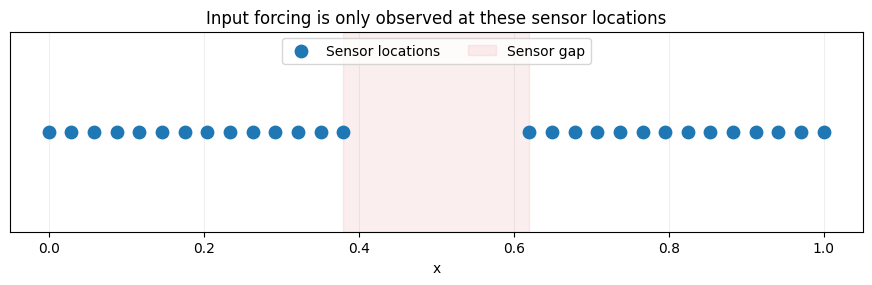

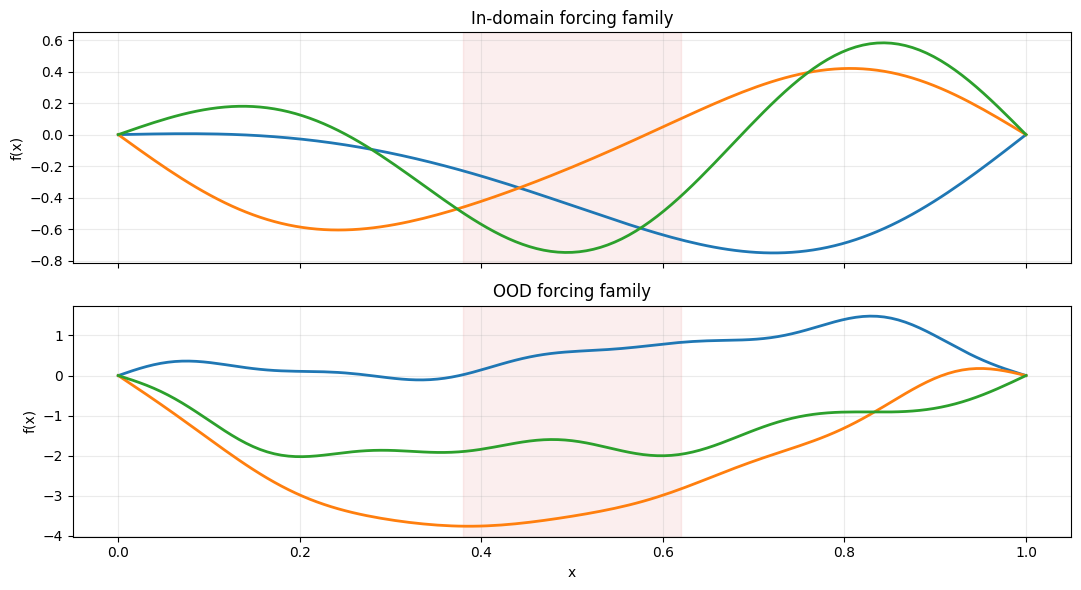

In [51]:
# Sensor-layout and forcing-family plots
# - First figure: where the model is actually given input data.
# - Second figure: examples of in-domain vs OOD source fields.
# - The shaded middle region is the spatial 'information gap' that should later show larger uncertainty.

# Visualize the sensor layout and the training/OOD source families

def shade_sensor_gap(ax):
    ax.axvspan(config.sensor_left_end, config.sensor_right_start, color='tab:red', alpha=0.08, label='Sensor gap')

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.scatter(sensor_grid.numpy(), np.zeros_like(sensor_grid.numpy()), s=80, color='tab:blue', zorder=3, label='Sensor locations')
shade_sensor_gap(ax)
ax.set_title('Input forcing is only observed at these sensor locations')
ax.set_xlabel('x')
ax.set_yticks([])
ax.legend(loc='upper center', ncols=2)
ax.grid(alpha=0.2)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for idx in range(3):
    axes[0].plot(query_grid.numpy(), train_data['forcing_query'][idx].numpy(), lw=2)
    axes[1].plot(query_grid.numpy(), ood_data['forcing_query'][idx].numpy(), lw=2)
for ax, title in zip(axes, ['In-domain forcing family', 'OOD forcing family']):
    shade_sensor_gap(ax)
    ax.set_title(title)
    ax.set_ylabel('f(x)')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('x')
plt.tight_layout()
plt.show()



## Baseline vs true solution

Before training DeepONet, we already have a deterministic baseline:

1. interpolate the sparse forcing measurements to the fine grid,
2. solve the Poisson problem with that interpolated forcing.

This baseline is physically reasonable, but it is not exact because it cannot recover unresolved source structure inside the sensor gap.

The network therefore learns only the **residual correction**.


Baseline test RMSE: 0.002616
Baseline OOD RMSE:  0.005867


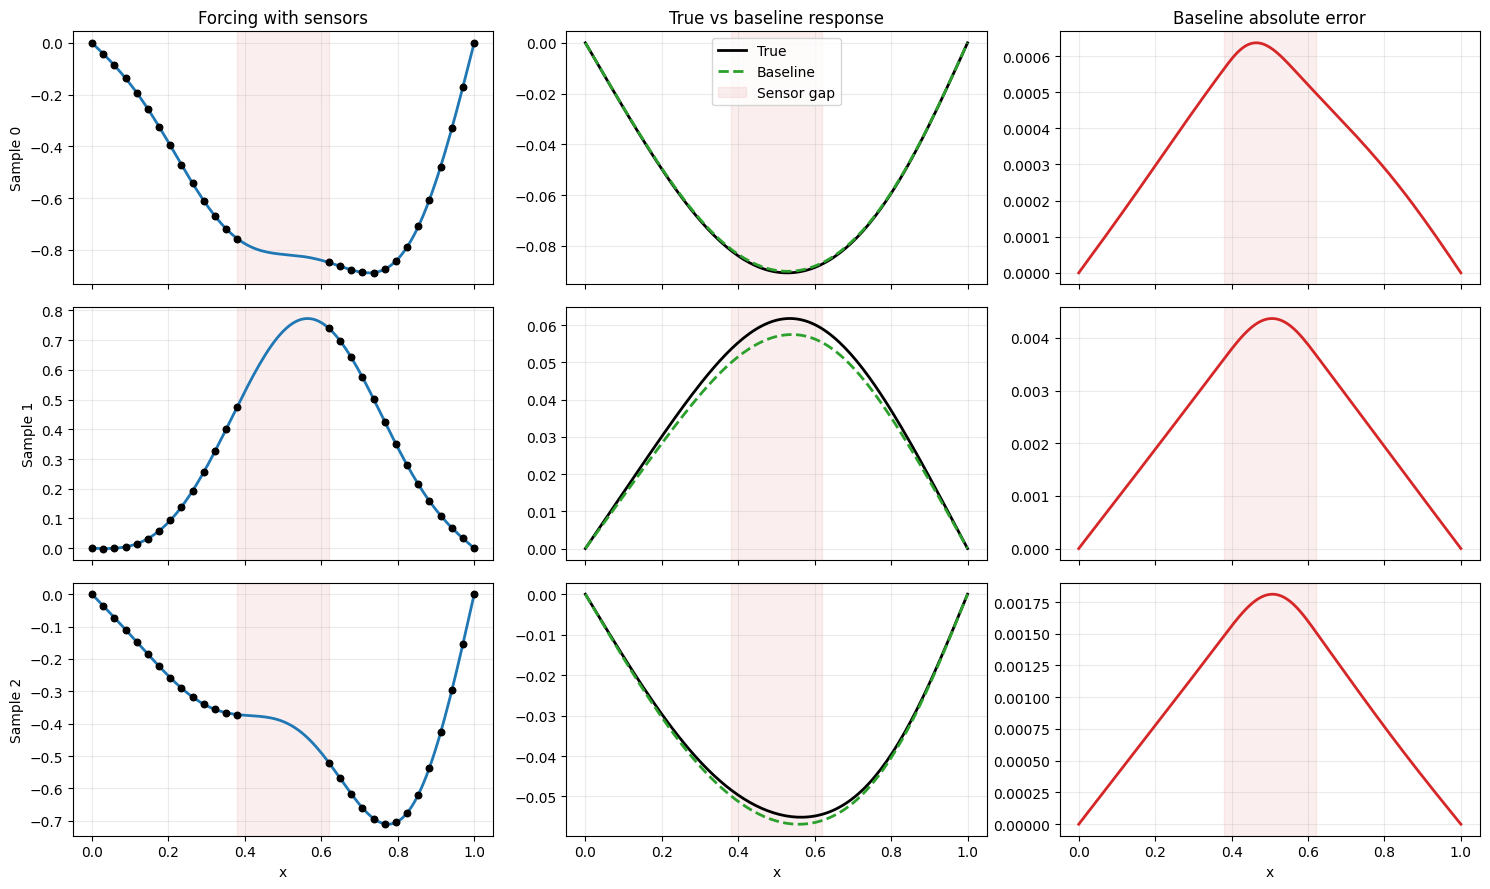

In [52]:
# Baseline diagnostics
# - This is the non-learned reference obtained from sparse sensing + interpolation + PDE solve.
# - It is already physically sensible, but it cannot fully recover structure hidden inside the sensor gap.
# - The learned residual model should improve on this baseline, especially in the difficult middle region.

# Baseline diagnostics

def summarize_rmse(pred: torch.Tensor, target: torch.Tensor) -> float:
    return math.sqrt(torch.mean((pred - target) ** 2).item())

baseline_test_rmse = summarize_rmse(test_data['baseline_solution'], test_data['true_solution'])
baseline_ood_rmse = summarize_rmse(ood_data['baseline_solution'], ood_data['true_solution'])
print(f'Baseline test RMSE: {baseline_test_rmse:.6f}')
print(f'Baseline OOD RMSE:  {baseline_ood_rmse:.6f}')

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for row, idx in enumerate([0, 1, 2]):
    forcing = test_data['forcing_query'][idx]
    true = test_data['true_solution'][idx]
    baseline = test_data['baseline_solution'][idx]

    axes[row, 0].plot(query_grid.numpy(), forcing.numpy(), color='tab:blue', lw=2)
    axes[row, 0].scatter(sensor_grid.numpy(), test_data['forcing_sensor'][idx].numpy(), color='black', s=22, zorder=3)
    shade_sensor_gap(axes[row, 0])
    axes[row, 0].set_title('Forcing with sensors' if row == 0 else '')
    axes[row, 0].set_ylabel(f'Sample {idx}')
    axes[row, 0].grid(alpha=0.25)

    axes[row, 1].plot(query_grid.numpy(), true.numpy(), color='black', lw=2, label='True')
    axes[row, 1].plot(query_grid.numpy(), baseline.numpy(), color='tab:green', lw=2, ls='--', label='Baseline')
    shade_sensor_gap(axes[row, 1])
    axes[row, 1].set_title('True vs baseline response' if row == 0 else '')
    axes[row, 1].grid(alpha=0.25)
    if row == 0:
        axes[row, 1].legend(loc='best')

    axes[row, 2].plot(query_grid.numpy(), (baseline - true).abs().numpy(), color='tab:red', lw=2)
    shade_sensor_gap(axes[row, 2])
    axes[row, 2].set_title('Baseline absolute error' if row == 0 else '')
    axes[row, 2].grid(alpha=0.25)

for ax in axes[-1]:
    ax.set_xlabel('x')
plt.tight_layout()
plt.show()


### What to look for in the baseline plots

A good first question is: *where does the baseline fail?*

Because the forcing field is sparsely observed, interpolation is least reliable in the middle of the domain. The baseline error should therefore often rise in or near that region.

This gives the learned correction a clear role: repair what sparse sensing cannot reconstruct on its own.


## DeepONet model

We wrap `DeepONet1D` inside a residual architecture:

$$
\hat u(x) = u_{\mathrm{baseline}}(x) + r_{\theta}(x),
$$

where $r_{\theta}(x)$ is the learned correction.

This is the main reason the fit becomes so accurate:

- the physics baseline solves most of the problem,
- the network only corrects the interpolation error induced by sparse sensing.


In [53]:
# Residual DeepONet model
# - `baseline_solution(...)` reconstructs the deterministic physics-based approximation.
# - `operator(...)` predicts a standardized residual correction on the fixed query grid.
# - The final prediction is baseline + learned correction.
# - This decomposition is what makes the fit much tighter than training a free-form field predictor from scratch.

# Residual DeepONet model

class ResidualPoissonDeepONet1D(nn.Module):
    def __init__(
        self,
        *,
        sensor_grid: torch.Tensor,
        query_grid: torch.Tensor,
        x_standardizer: Standardizer,
        residual_standardizer: Standardizer,
        latent_dim: int,
        hidden_dim: int,
        depth: int,
    ) -> None:
        super().__init__()
        self.operator = DeepONet1D(
            branch_input_dim=sensor_grid.numel(),
            latent_dim=latent_dim,
            hidden_dim=hidden_dim,
            depth=depth,
            query_grid=query_grid.unsqueeze(-1),
        )
        self.register_buffer('sensor_grid', sensor_grid)
        self.register_buffer('query_grid', query_grid)
        self.register_buffer('x_mean', x_standardizer.mean)
        self.register_buffer('x_std', x_standardizer.std)
        self.register_buffer('residual_mean', residual_standardizer.mean)
        self.register_buffer('residual_std', residual_standardizer.std)

    def baseline_solution(self, x_std_input: torch.Tensor) -> torch.Tensor:
        forcing_sensor = x_std_input * self.x_std + self.x_mean
        forcing_query = interpolate_sensor_values(self.sensor_grid, forcing_sensor, self.query_grid)
        return solve_poisson_dirichlet_batch(forcing_query)

    def standardized_residual(self, x_std_input: torch.Tensor) -> torch.Tensor:
        return self.operator(x_std_input)

    def residual_correction(self, x_std_input: torch.Tensor) -> torch.Tensor:
        residual_std = self.standardized_residual(x_std_input)
        return residual_std * self.residual_std + self.residual_mean

    def forward(self, x_std_input: torch.Tensor) -> torch.Tensor:
        return self.baseline_solution(x_std_input) + self.residual_correction(x_std_input)


model = ResidualPoissonDeepONet1D(
    sensor_grid=sensor_grid,
    query_grid=query_grid,
    x_standardizer=x_standardizer,
    residual_standardizer=residual_standardizer,
    latent_dim=config.latent_dim,
    hidden_dim=config.hidden_dim,
    depth=config.depth,
).to(device)

model


ResidualPoissonDeepONet1D(
  (operator): DeepONet1D(
    (branch_net): Sequential(
      (0): Linear(in_features=28, out_features=160, bias=True)
      (1): Tanh()
      (2): Linear(in_features=160, out_features=160, bias=True)
      (3): Tanh()
      (4): Linear(in_features=160, out_features=160, bias=True)
      (5): Tanh()
      (6): Linear(in_features=160, out_features=160, bias=True)
    )
    (trunk_net): Sequential(
      (0): Linear(in_features=1, out_features=160, bias=True)
      (1): Tanh()
      (2): Linear(in_features=160, out_features=160, bias=True)
      (3): Tanh()
      (4): Linear(in_features=160, out_features=160, bias=True)
      (5): Tanh()
      (6): Linear(in_features=160, out_features=160, bias=True)
    )
    (output_head): Linear(in_features=160, out_features=1, bias=True)
  )
)


## Training setup

The model is trained on the **full physical solution field**, not just the residual target.

That is important conceptually:

- the baseline is part of the model,
- the loss still measures accuracy on the real response field,
- the residual formulation only changes how the model represents the solution.

The Laplace fit later is applied to the standardized residual operator, which is the learned component.


In [54]:
# Data loaders
# - `train_loader` / `val_loader` supervise the physical full-field prediction.
# - `train_residual_loader` is reserved for Laplace later, because Laplace is fitted to the learned residual operator rather than the full baseline+residual model.

# Data loaders

train_loader = DataLoader(
    TensorDataset(train_x, train_data['true_solution']),
    batch_size=config.batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_x, val_data['true_solution']),
    batch_size=config.batch_size,
    shuffle=False,
)
train_residual_loader = DataLoader(
    TensorDataset(train_x, train_residual_std),
    batch_size=config.batch_size,
    shuffle=True,
)


In [55]:
# Evaluation helpers
# - `predict_in_batches` keeps inference simple and memory-safe.
# - `evaluate_model` reports both RMSE and relative L2 error so a reader can judge absolute and normalized fit quality.

# Training and evaluation helpers

def relative_l2(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    numerator = torch.linalg.norm(pred - target, dim=1)
    denominator = torch.linalg.norm(target, dim=1).clamp_min(eps)
    return numerator / denominator


@torch.no_grad()
def predict_in_batches(model: nn.Module, x_tensor: torch.Tensor, batch_size: int = 128) -> torch.Tensor:
    model.eval()
    outputs = []
    for start in range(0, len(x_tensor), batch_size):
        xb = x_tensor[start:start + batch_size].to(device)
        outputs.append(model(xb).cpu())
    return torch.cat(outputs, dim=0)


@torch.no_grad()
def evaluate_model(model: nn.Module, x_tensor: torch.Tensor, y_tensor: torch.Tensor):
    pred = predict_in_batches(model, x_tensor)
    mse = torch.mean((pred - y_tensor) ** 2).item()
    rmse = math.sqrt(mse)
    rel = float(relative_l2(pred, y_tensor).mean())
    return {'rmse': rmse, 'rel_l2': rel, 'pred': pred}


In [56]:
# MAP training loop
# - We optimize the full physical solution error, not only the residual error.
# - OneCycle learning rate scheduling helps the residual model converge faster and more stably.
# - Early stopping is optional; if enabled, it protects against unnecessary late-epoch drift.

# MAP training loop

optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config.max_lr,
    steps_per_epoch=len(train_loader),
    epochs=config.epochs,
    pct_start=0.12,
)

history = {
    'train_rmse': [],
    'val_rmse': [],
    'train_rel_l2': [],
    'val_rel_l2': [],
    'lr': [],
}

best_state = copy.deepcopy(model.state_dict())
best_val_rmse = float('inf')
epochs_without_improvement = 0

for epoch in range(config.epochs):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = nn.functional.mse_loss(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip)
        optimizer.step()
        scheduler.step()

    train_metrics = evaluate_model(model, train_x[:160], train_data['true_solution'][:160])
    val_metrics = evaluate_model(model, val_x, val_data['true_solution'])

    history['train_rmse'].append(train_metrics['rmse'])
    history['val_rmse'].append(val_metrics['rmse'])
    history['train_rel_l2'].append(train_metrics['rel_l2'])
    history['val_rel_l2'].append(val_metrics['rel_l2'])
    history['lr'].append(optimizer.param_groups[0]['lr'])

    improved = val_metrics['rmse'] < (best_val_rmse - config.early_stopping_min_delta)
    if improved:
        best_val_rmse = val_metrics['rmse']
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:03d} | "
            f"train_rmse={train_metrics['rmse']:.6f} | "
            f"val_rmse={val_metrics['rmse']:.6f} | "
            f"val_rel_l2={val_metrics['rel_l2']:.5f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

    if (
        config.use_early_stopping
        and epoch + 1 >= config.min_epochs
        and epochs_without_improvement >= config.patience
    ):
        print(f'Early stopping at epoch {epoch + 1}.')
        break

model.load_state_dict(best_state)
print(f'Best validation RMSE: {best_val_rmse:.8f}')


Epoch 001 | train_rmse=0.002865 | val_rmse=0.002609 | val_rel_l2=0.10164 | lr=1.27e-04
Epoch 025 | train_rmse=0.000228 | val_rmse=0.000218 | val_rel_l2=0.00941 | lr=2.73e-03
Epoch 050 | train_rmse=0.000133 | val_rmse=0.000137 | val_rel_l2=0.00602 | lr=2.95e-03
Epoch 075 | train_rmse=0.000216 | val_rmse=0.000229 | val_rel_l2=0.00868 | lr=2.74e-03
Epoch 100 | train_rmse=0.000178 | val_rmse=0.000171 | val_rel_l2=0.00841 | lr=2.38e-03
Epoch 125 | train_rmse=0.000084 | val_rmse=0.000089 | val_rel_l2=0.00377 | lr=1.92e-03
Epoch 150 | train_rmse=0.000061 | val_rmse=0.000070 | val_rel_l2=0.00243 | lr=1.41e-03
Epoch 175 | train_rmse=0.000045 | val_rmse=0.000057 | val_rel_l2=0.00192 | lr=9.10e-04
Epoch 200 | train_rmse=0.000042 | val_rmse=0.000047 | val_rel_l2=0.00173 | lr=4.80e-04
Epoch 225 | train_rmse=0.000040 | val_rmse=0.000050 | val_rel_l2=0.00163 | lr=1.69e-04
Epoch 250 | train_rmse=0.000039 | val_rmse=0.000046 | val_rel_l2=0.00156 | lr=1.40e-05
Best validation RMSE: 0.00004585


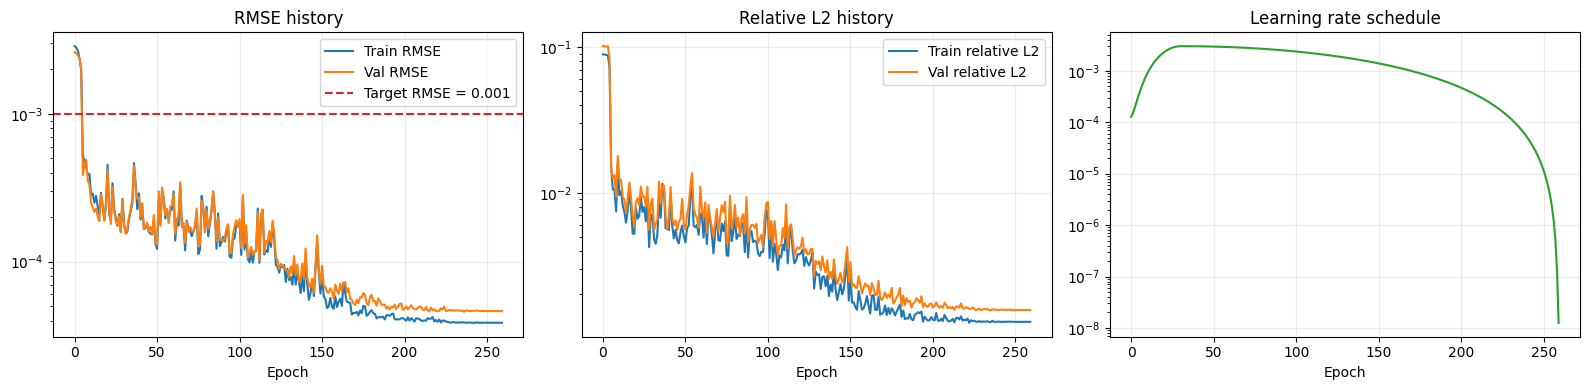

In [57]:
# Training curves
# - Left: did we reach the desired absolute error scale?
# - Middle: does the fit remain strong after normalizing by signal magnitude?
# - Right: what learning-rate schedule produced the training behavior?

# Training curves

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['train_rmse'], label='Train RMSE')
axes[0].plot(history['val_rmse'], label='Val RMSE')
axes[0].axhline(0.001, color='tab:red', ls='--', label='Target RMSE = 0.001')
axes[0].set_title('RMSE history')
axes[0].set_xlabel('Epoch')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history['train_rel_l2'], label='Train relative L2')
axes[1].plot(history['val_rel_l2'], label='Val relative L2')
axes[1].set_title('Relative L2 history')
axes[1].set_xlabel('Epoch')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(history['lr'], color='tab:green')
axes[2].set_title('Learning rate schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### How to read the training curves

The left panel is the most important one for this notebook. The horizontal dashed line marks the target error scale `0.001`.

If the validation RMSE falls below that line and stays there, the deterministic operator fit is already strong enough for the Laplace stage to be meaningful. The uncertainty layer should then describe *where the model is unsure*, not hide a badly trained predictor.


## MAP diagnostics

The deterministic model should now improve significantly over the interpolation-based baseline.

The next section compares:

- baseline error,
- MAP error,
- individual field predictions,
- aggregate accuracy.


In [58]:
# MAP accuracy summary
# - Compare the deterministic baseline against the trained residual DeepONet.
# - The main success criterion here is that the test RMSE falls below 0.001.
# - OOD error is expected to remain noticeably larger.

# MAP accuracy summary

map_test = evaluate_model(model, test_x, test_data['true_solution'])
map_ood = evaluate_model(model, ood_x, ood_data['true_solution'])

print(f"Baseline test RMSE: {baseline_test_rmse:.8f}")
print(f"MAP test RMSE:      {map_test['rmse']:.8f}")
print(f"Baseline OOD RMSE:  {baseline_ood_rmse:.8f}")
print(f"MAP OOD RMSE:       {map_ood['rmse']:.8f}")


Baseline test RMSE: 0.00261581
MAP test RMSE:      0.00004223
Baseline OOD RMSE:  0.00586683
MAP OOD RMSE:       0.00693154


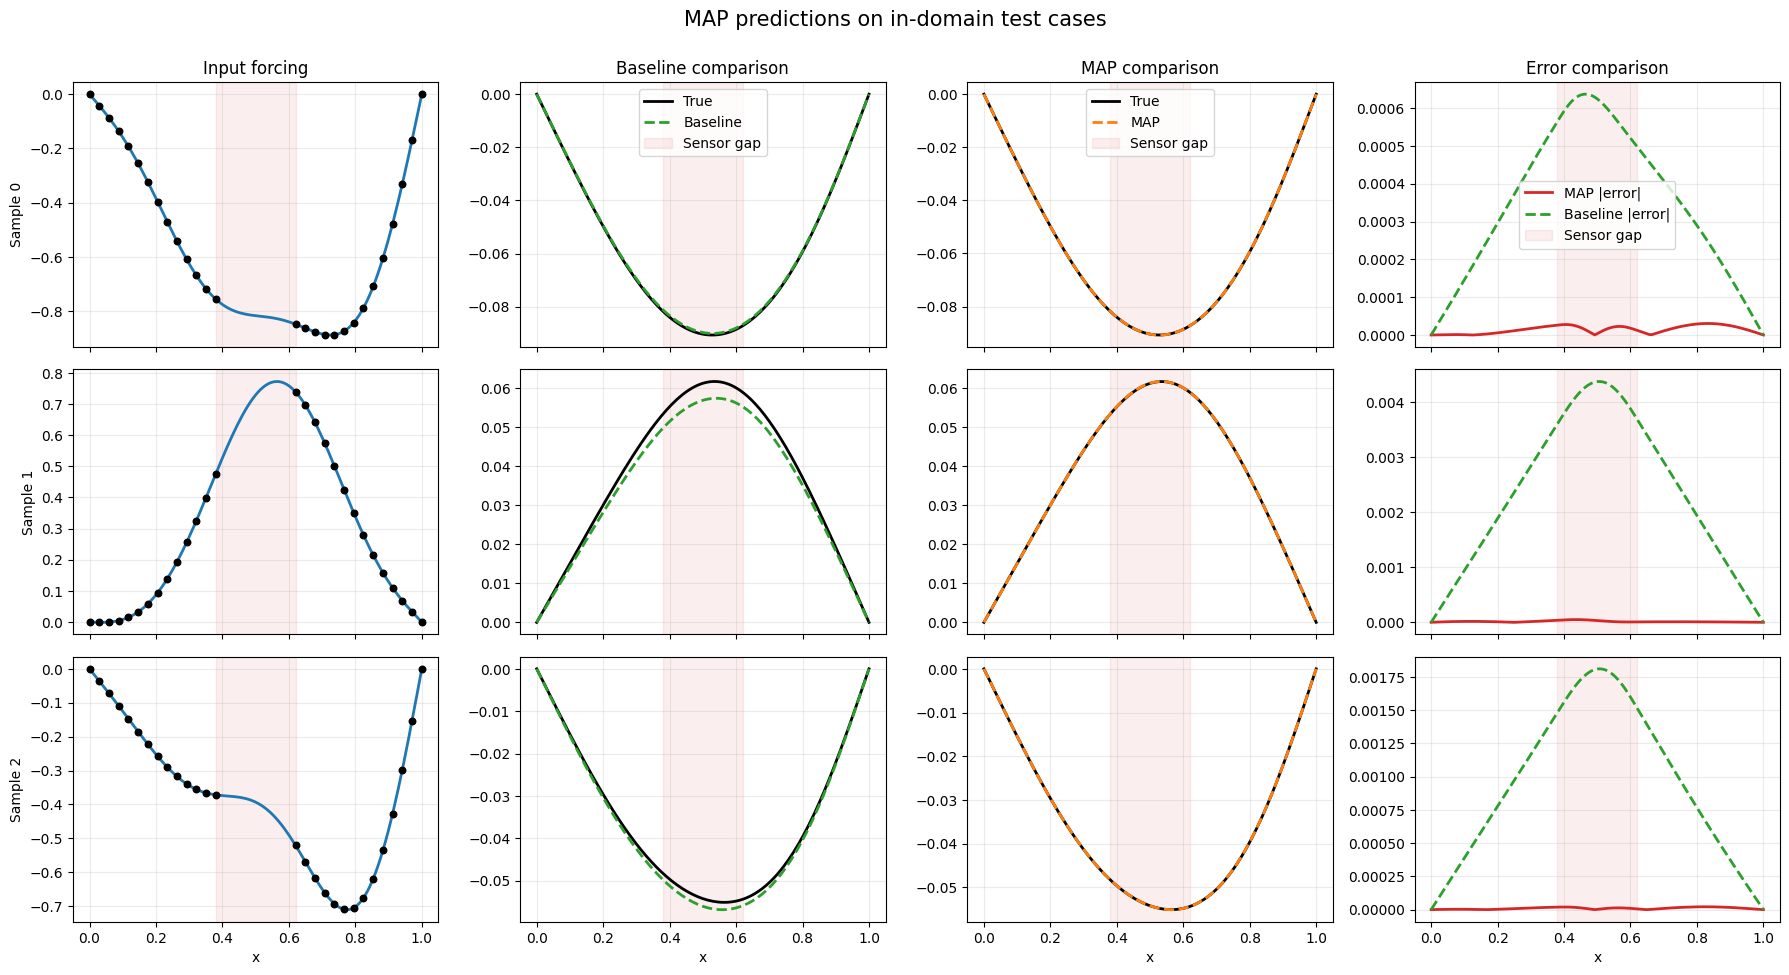

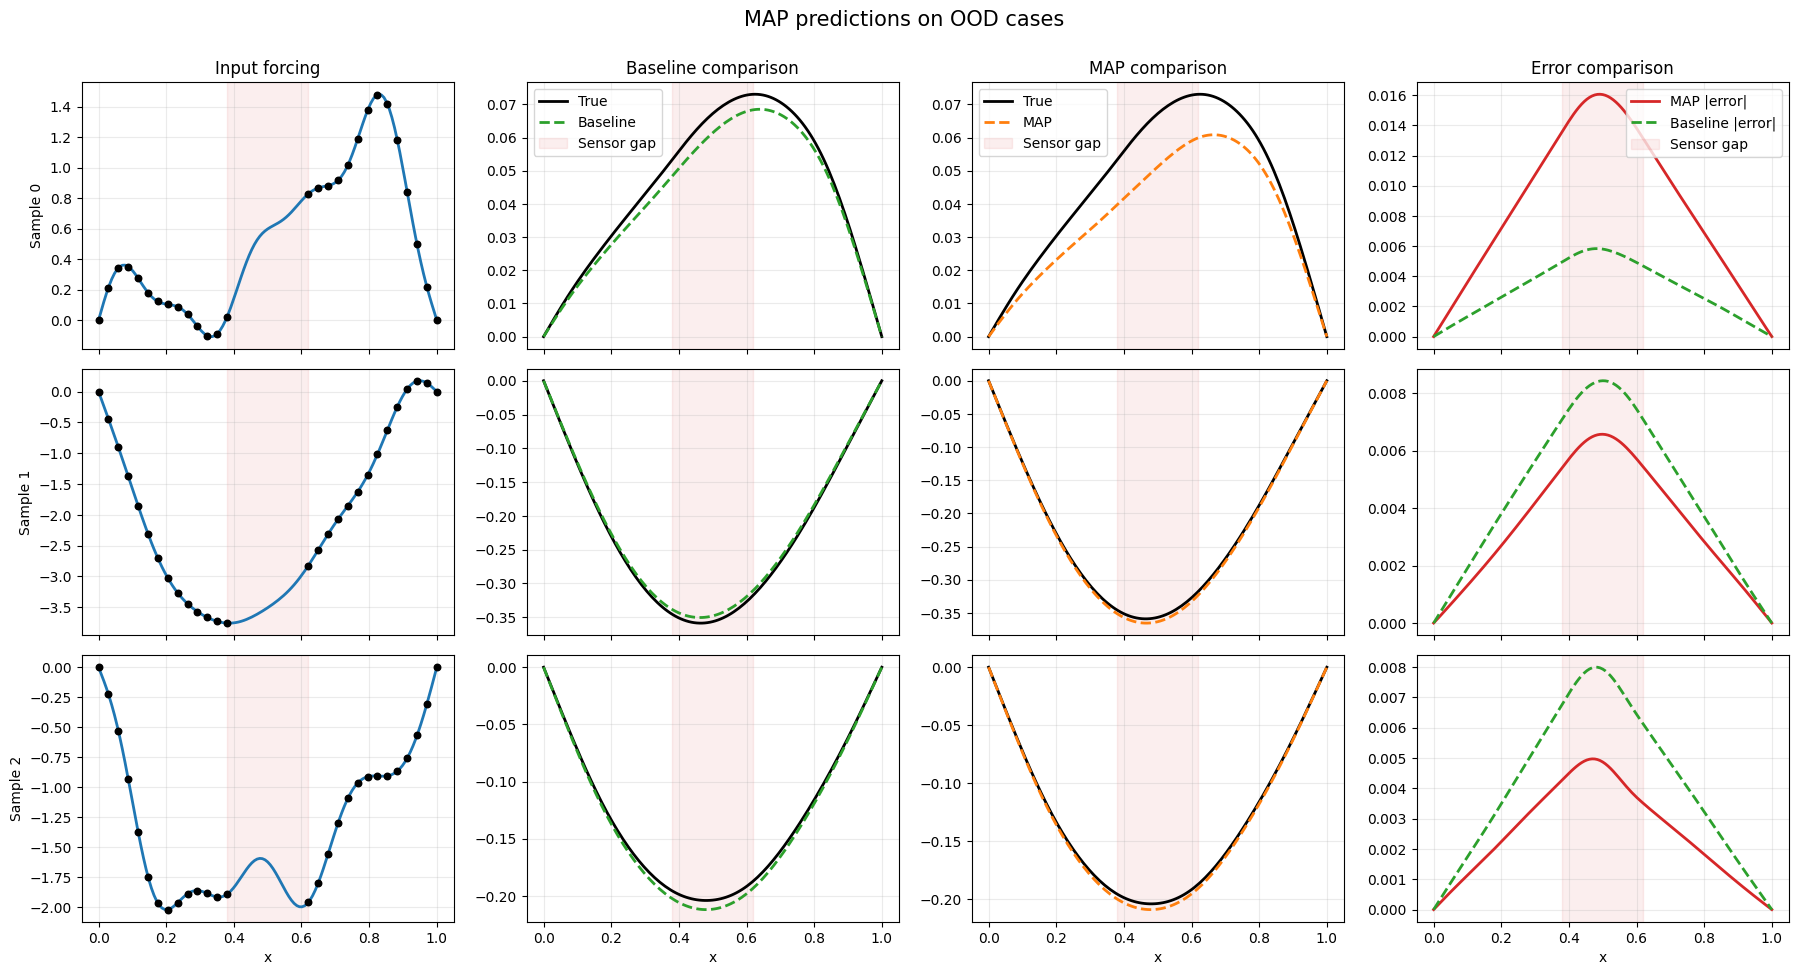

In [59]:
# Sample-wise MAP diagnostics
# - Column 1: the true forcing field and the sparse measurements actually observed by the model.
# - Column 2: how much the deterministic baseline misses.
# - Column 3: how closely the trained MAP model matches the true solution.
# - Column 4: whether the remaining error concentrates near the low-data region.

# Visualize how the residual DeepONet improves on the baseline

def plot_map_examples(dataset, map_pred, title: str, indices=(0, 1, 2)):
    fig, axes = plt.subplots(len(indices), 4, figsize=(18, 3.3 * len(indices)), sharex=True)
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, idx in enumerate(indices):
        forcing_query = dataset['forcing_query'][idx]
        forcing_sensor = dataset['forcing_sensor'][idx]
        true = dataset['true_solution'][idx]
        baseline = dataset['baseline_solution'][idx]
        pred = map_pred[idx]

        axes[row, 0].plot(query_grid.numpy(), forcing_query.numpy(), color='tab:blue', lw=2)
        axes[row, 0].scatter(sensor_grid.numpy(), forcing_sensor.numpy(), color='black', s=22, zorder=3)
        shade_sensor_gap(axes[row, 0])
        axes[row, 0].set_title('Input forcing' if row == 0 else '')
        axes[row, 0].set_ylabel(f'Sample {idx}')
        axes[row, 0].grid(alpha=0.25)

        axes[row, 1].plot(query_grid.numpy(), true.numpy(), color='black', lw=2, label='True')
        axes[row, 1].plot(query_grid.numpy(), baseline.numpy(), color='tab:green', lw=2, ls='--', label='Baseline')
        shade_sensor_gap(axes[row, 1])
        axes[row, 1].set_title('Baseline comparison' if row == 0 else '')
        axes[row, 1].grid(alpha=0.25)
        if row == 0:
            axes[row, 1].legend(loc='best')

        axes[row, 2].plot(query_grid.numpy(), true.numpy(), color='black', lw=2, label='True')
        axes[row, 2].plot(query_grid.numpy(), pred.numpy(), color='tab:orange', lw=2, ls='--', label='MAP')
        shade_sensor_gap(axes[row, 2])
        axes[row, 2].set_title('MAP comparison' if row == 0 else '')
        axes[row, 2].grid(alpha=0.25)
        if row == 0:
            axes[row, 2].legend(loc='best')

        axes[row, 3].plot(query_grid.numpy(), (pred - true).abs().numpy(), color='tab:red', lw=2, label='MAP |error|')
        axes[row, 3].plot(query_grid.numpy(), (baseline - true).abs().numpy(), color='tab:green', lw=2, ls='--', label='Baseline |error|')
        shade_sensor_gap(axes[row, 3])
        axes[row, 3].set_title('Error comparison' if row == 0 else '')
        axes[row, 3].grid(alpha=0.25)
        if row == 0:
            axes[row, 3].legend(loc='best')

    for ax in axes[-1]:
        ax.set_xlabel('x')
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_map_examples(test_data, map_test['pred'], 'MAP predictions on in-domain test cases')
plot_map_examples(ood_data, map_ood['pred'], 'MAP predictions on OOD cases')


### Reading the MAP diagnostics

These panels answer two practical questions:

1. Does the residual DeepONet actually improve on the interpolation baseline?
2. Where do the remaining errors live spatially?

If the last column still spikes in the sensor-gap region, that is a good sign for the later uncertainty plots: it means the hard part of the problem is still localized in the place where information is weakest.


## Laplace approximation on the learned residual

The deterministic baseline is fixed. The learned correction is the uncertain part.

So for Laplace we fit uncertainty only on the DeepONet residual operator:

$$
\hat u(x) = u_{\mathrm{baseline}}(x) + r_{\theta}(x),
$$

and place the last-layer Laplace posterior on $r_{\theta}$.

This is the most logical uncertainty split for this notebook:

- deterministic PDE baseline: known and fixed,
- learned residual correction: uncertain and data-driven.


In [60]:
# Laplace fit on the residual operator
# - The baseline stays deterministic.
# - Laplace is only used on the learned correction, which is the epistemically uncertain component.
# - We transform the residual mean/variance back to physical units before plotting bands.

# Fit last-layer diagonal Laplace on the standardized residual operator

laplace = LaplaceWrapper(
    model.operator,
    likelihood='regression',
    hessian_structure='diag',
    subset_of_weights='last_layer',
)
laplace.fit(train_residual_loader, prior_precision=config.laplace_prior_precision)

@torch.no_grad()
def predict_laplace_physical(x_tensor: torch.Tensor, batch_size: int = 128):
    mean_list, epi_list, total_list = [], [], []
    for start in range(0, len(x_tensor), batch_size):
        xb = x_tensor[start:start + batch_size].to(device)
        base = model.baseline_solution(xb).cpu()
        uq = laplace.predict_uq(xb, n_samples=config.laplace_samples)

        residual_mean = residual_standardizer.inverse(uq.mean.cpu())
        residual_epi = residual_standardizer.inverse_var(uq.epistemic_var.cpu())
        residual_total = residual_standardizer.inverse_var(uq.total_var.cpu())

        mean_list.append(base + residual_mean)
        epi_list.append(residual_epi)
        total_list.append(residual_total)

    return torch.cat(mean_list), torch.cat(epi_list), torch.cat(total_list)

lap_test_mean, lap_test_epi_var, lap_test_total_var = predict_laplace_physical(test_x)
lap_ood_mean, lap_ood_epi_var, lap_ood_total_var = predict_laplace_physical(ood_x)

lap_test_rmse = summarize_rmse(lap_test_mean, test_data['true_solution'])
lap_ood_rmse = summarize_rmse(lap_ood_mean, ood_data['true_solution'])

print(f'Laplace test RMSE: {lap_test_rmse:.8f}')
print(f'Laplace OOD RMSE:  {lap_ood_rmse:.8f}')


Laplace test RMSE: 0.00004724
Laplace OOD RMSE:  0.00695627


### Why the Laplace fit is done on the residual model

This is an important modeling choice. The deterministic baseline comes from a known numerical procedure, so it does not make sense to treat it as Bayesian model uncertainty. The uncertain part is the **learned residual correction**.

By placing Laplace only on the residual operator, the predictive variance is tied directly to the learned component that depends on data support.

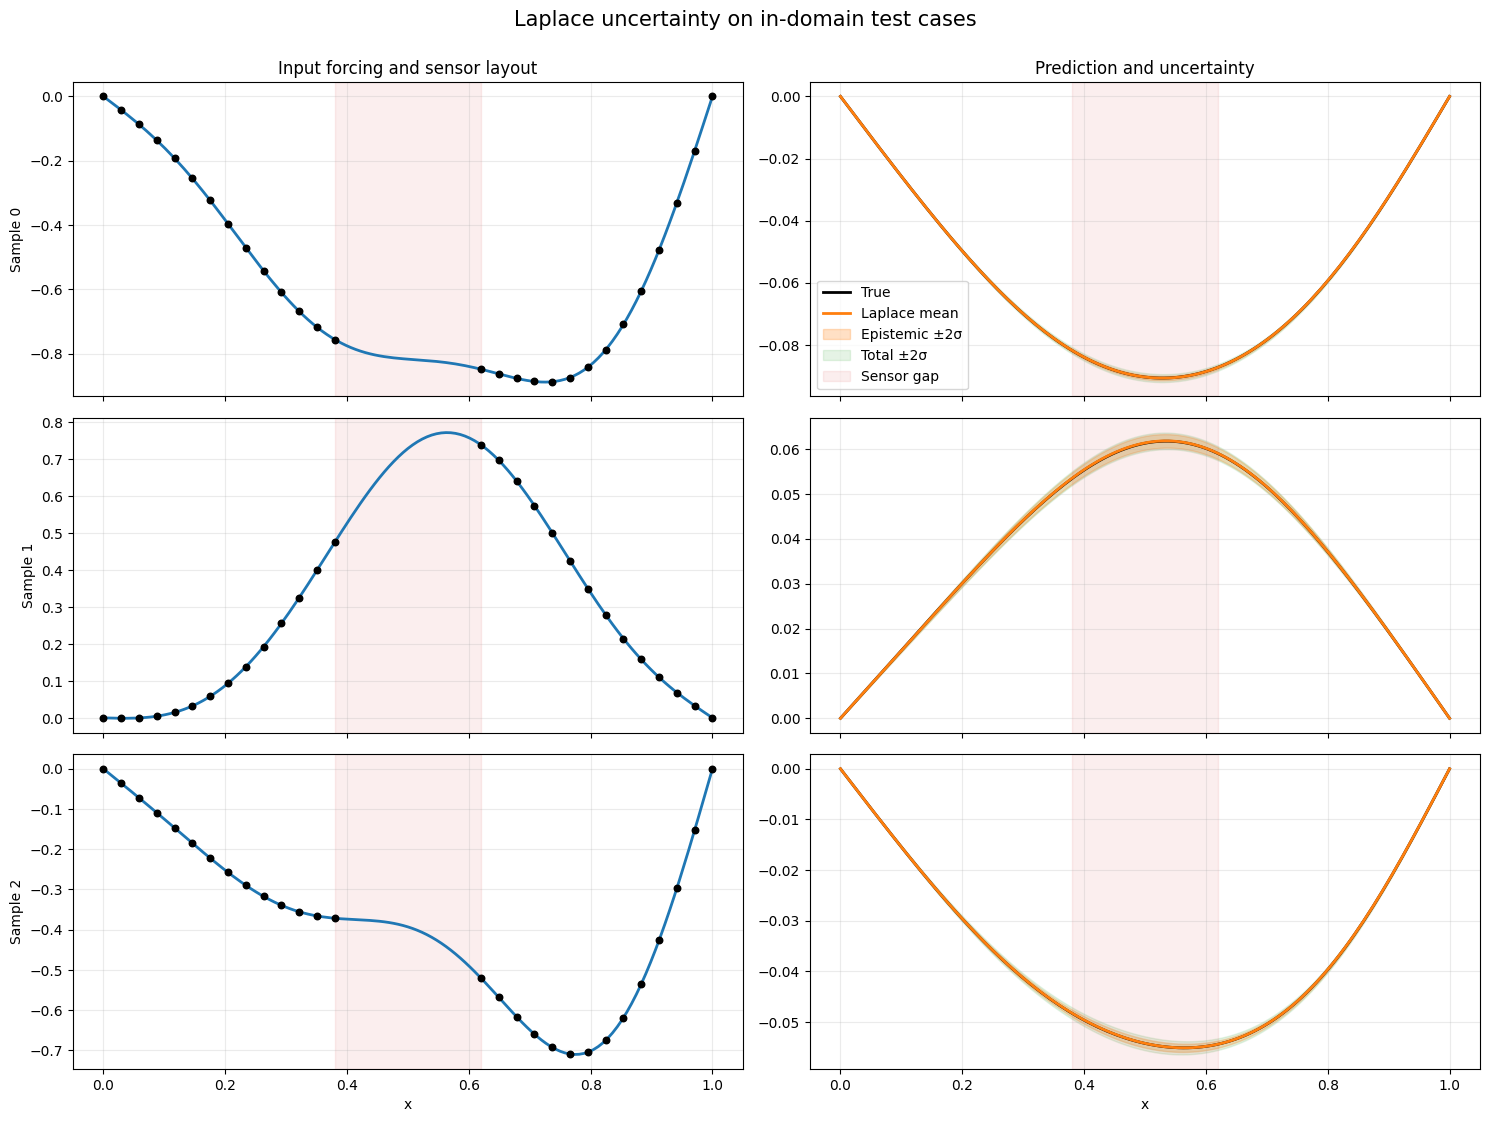

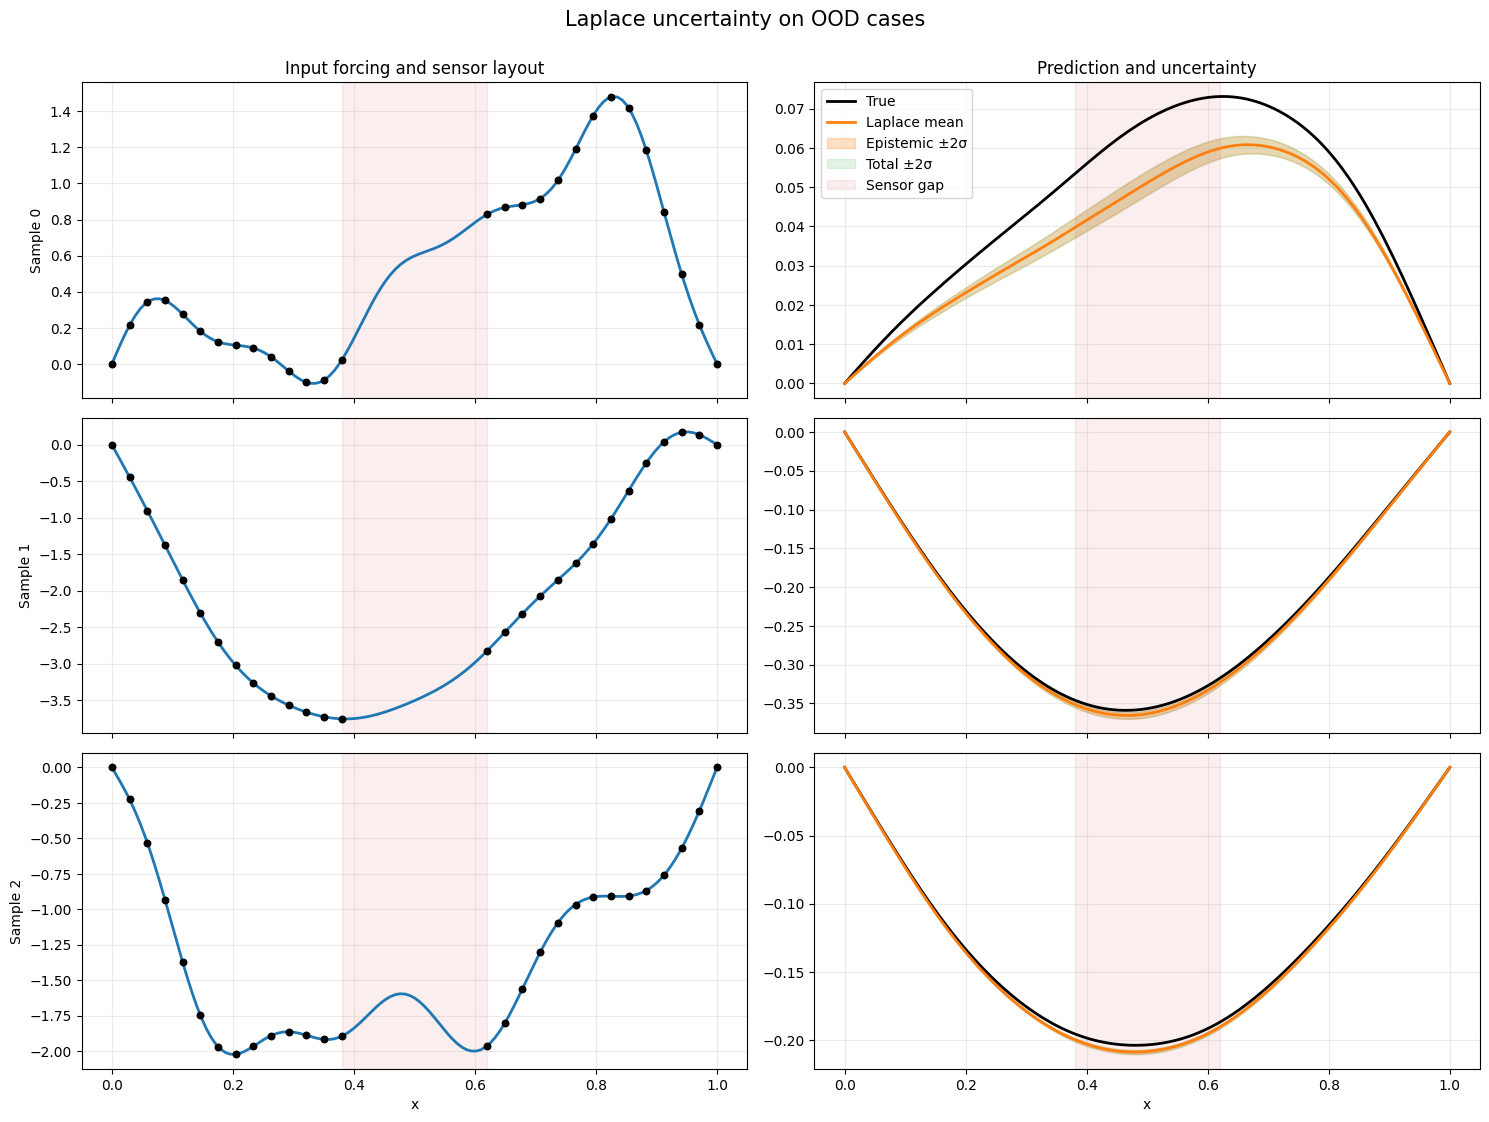

In [61]:
# Predictive bands
# - Orange band: epistemic uncertainty from the Laplace posterior over the learned correction.
# - Green band: total predictive uncertainty (same as epistemic here, because there is no extra aleatoric observation-noise model).
# - The key visual question is whether the band expands inside the sensor gap and on OOD examples.

# Show predictive bands and highlight the low-data region

def plot_uq_examples(dataset, mean, epi_var, total_var, title: str, indices=(0, 1, 2)):
    fig, axes = plt.subplots(len(indices), 2, figsize=(15, 3.8 * len(indices)), sharex=True)
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, idx in enumerate(indices):
        forcing_query = dataset['forcing_query'][idx]
        forcing_sensor = dataset['forcing_sensor'][idx]
        true = dataset['true_solution'][idx]
        pred_mean = mean[idx]
        epi_std = epi_var[idx].sqrt()
        total_std = total_var[idx].sqrt()

        axes[row, 0].plot(query_grid.numpy(), forcing_query.numpy(), color='tab:blue', lw=2)
        axes[row, 0].scatter(sensor_grid.numpy(), forcing_sensor.numpy(), color='black', s=22, zorder=3)
        shade_sensor_gap(axes[row, 0])
        axes[row, 0].set_title('Input forcing and sensor layout' if row == 0 else '')
        axes[row, 0].set_ylabel(f'Sample {idx}')
        axes[row, 0].grid(alpha=0.25)

        axes[row, 1].plot(query_grid.numpy(), true.numpy(), color='black', lw=2, label='True')
        axes[row, 1].plot(query_grid.numpy(), pred_mean.numpy(), color='tab:orange', lw=2, label='Laplace mean')
        axes[row, 1].fill_between(
            query_grid.numpy(),
            (pred_mean - 2.0 * epi_std).numpy(),
            (pred_mean + 2.0 * epi_std).numpy(),
            color='tab:orange',
            alpha=0.24,
            label='Epistemic ±2σ' if row == 0 else None,
        )
        axes[row, 1].fill_between(
            query_grid.numpy(),
            (pred_mean - 2.0 * total_std).numpy(),
            (pred_mean + 2.0 * total_std).numpy(),
            color='tab:green',
            alpha=0.12,
            label='Total ±2σ' if row == 0 else None,
        )
        shade_sensor_gap(axes[row, 1])
        axes[row, 1].set_title('Prediction and uncertainty' if row == 0 else '')
        axes[row, 1].grid(alpha=0.25)
        if row == 0:
            axes[row, 1].legend(loc='best')

    for ax in axes[-1]:
        ax.set_xlabel('x')
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_uq_examples(test_data, lap_test_mean, lap_test_epi_var, lap_test_total_var, 'Laplace uncertainty on in-domain test cases')
plot_uq_examples(ood_data, lap_ood_mean, lap_ood_epi_var, lap_ood_total_var, 'Laplace uncertainty on OOD cases')


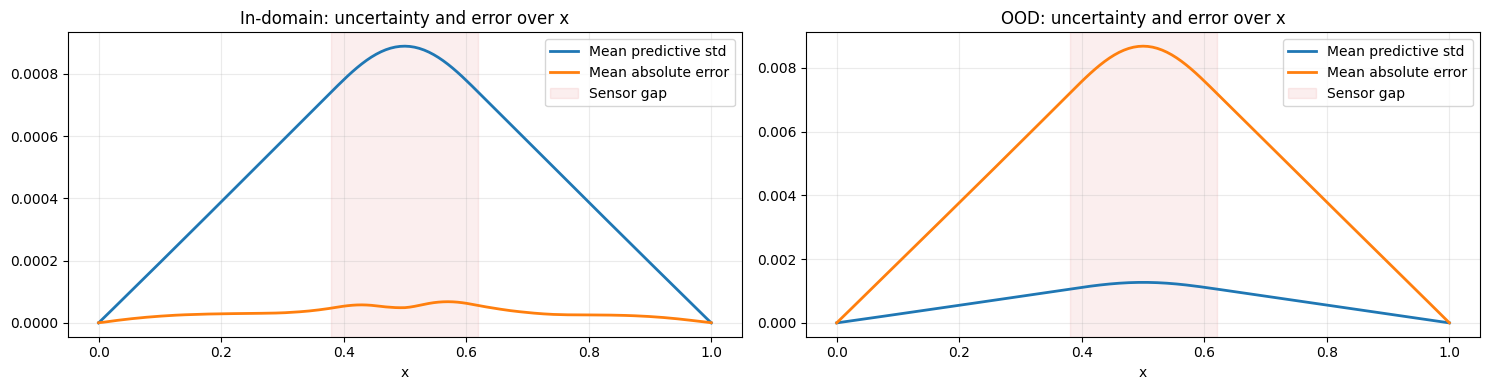

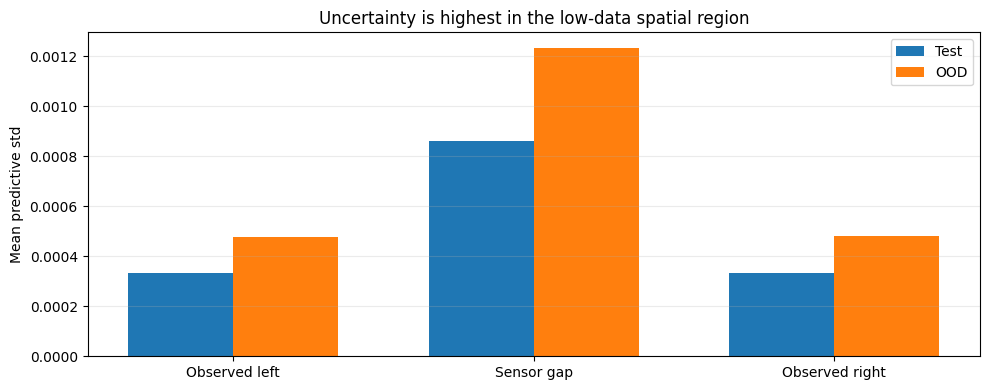

Test region stds: {'Observed left': 0.0003342016425449401, 'Sensor gap': 0.0008622874738648534, 'Observed right': 0.00033357905340380967}
OOD region stds:  {'Observed left': 0.0004757510614581406, 'Sensor gap': 0.0012342074187472463, 'Observed right': 0.0004797786823473871}


In [62]:
# Aggregate uncertainty diagnostics
# - The line plots show where uncertainty and error concentrate along x.
# - The bar chart compresses that into three interpretable spatial regions:
#     observed left, sensor gap, observed right.
# - This is the clearest summary for learners: uncertainty should peak in the gap.

# Aggregate uncertainty and error over the domain

def region_mean(curve: torch.Tensor, mask: torch.Tensor) -> float:
    return curve[mask].mean().item()

mean_test_total_std = lap_test_total_var.sqrt().mean(dim=0)
mean_ood_total_std = lap_ood_total_var.sqrt().mean(dim=0)
mean_test_error = (lap_test_mean - test_data['true_solution']).abs().mean(dim=0)
mean_ood_error = (lap_ood_mean - ood_data['true_solution']).abs().mean(dim=0)

left_mask = query_grid <= 0.35
gap_mask = (query_grid >= 0.42) & (query_grid <= 0.58)
right_mask = query_grid >= 0.65

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True)
for ax, std_curve, err_curve, title in [
    (axes[0], mean_test_total_std, mean_test_error, 'In-domain'),
    (axes[1], mean_ood_total_std, mean_ood_error, 'OOD'),
]:
    ax.plot(query_grid.numpy(), std_curve.numpy(), label='Mean predictive std', lw=2)
    ax.plot(query_grid.numpy(), err_curve.numpy(), label='Mean absolute error', lw=2)
    shade_sensor_gap(ax)
    ax.set_title(f'{title}: uncertainty and error over x')
    ax.set_xlabel('x')
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

region_labels = ['Observed left', 'Sensor gap', 'Observed right']
test_region_std = [
    region_mean(mean_test_total_std, left_mask),
    region_mean(mean_test_total_std, gap_mask),
    region_mean(mean_test_total_std, right_mask),
]
ood_region_std = [
    region_mean(mean_ood_total_std, left_mask),
    region_mean(mean_ood_total_std, gap_mask),
    region_mean(mean_ood_total_std, right_mask),
]

xpos = np.arange(len(region_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(xpos - width / 2, test_region_std, width, label='Test')
ax.bar(xpos + width / 2, ood_region_std, width, label='OOD')
ax.set_xticks(xpos)
ax.set_xticklabels(region_labels)
ax.set_ylabel('Mean predictive std')
ax.set_title('Uncertainty is highest in the low-data spatial region')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('Test region stds:', dict(zip(region_labels, test_region_std)))
print('OOD region stds: ', dict(zip(region_labels, ood_region_std)))


### The main uncertainty result

The bar chart below is the clearest summary in the notebook. It compresses the spatial uncertainty into three interpretable regions:

- left observed region,
- middle sensor-gap region,
- right observed region.

A successful result is: **middle > left and middle > right**, with the gap even more pronounced on OOD samples.

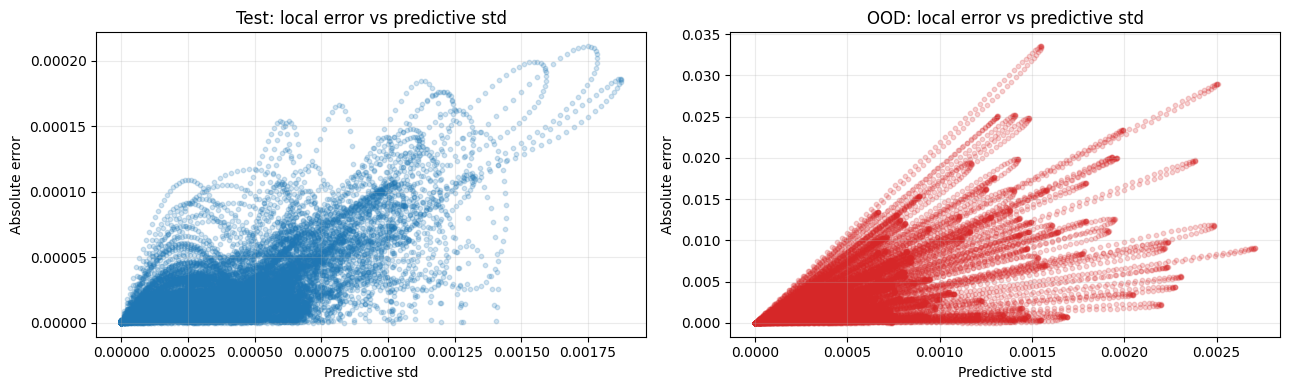

In [63]:
# Local error vs uncertainty
# - These scatter plots ask whether large predictive standard deviation tends to coincide with large actual error.
# - The OOD panel is especially useful because it reveals whether the method becomes less confident when the forcing family shifts.

# Local error vs uncertainty scatter

test_abs_error = (lap_test_mean - test_data['true_solution']).abs().reshape(-1)
ood_abs_error = (lap_ood_mean - ood_data['true_solution']).abs().reshape(-1)
test_std_flat = lap_test_total_var.sqrt().reshape(-1)
ood_std_flat = lap_ood_total_var.sqrt().reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(test_std_flat.numpy(), test_abs_error.numpy(), s=10, alpha=0.2, color='tab:blue')
axes[0].set_title('Test: local error vs predictive std')
axes[0].set_xlabel('Predictive std')
axes[0].set_ylabel('Absolute error')
axes[0].grid(alpha=0.25)

axes[1].scatter(ood_std_flat.numpy(), ood_abs_error.numpy(), s=10, alpha=0.2, color='tab:red')
axes[1].set_title('OOD: local error vs predictive std')
axes[1].set_xlabel('Predictive std')
axes[1].set_ylabel('Absolute error')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()



## Optional: diagonal vs Kronecker Laplace

The main notebook uses last-layer diagonal Laplace because it is the simplest stable choice.

If you want a structure comparison, enable `config.compare_kron = True` and run the next cell.


In [64]:
# Optional structure comparison
# - This section is intentionally secondary.
# - The main tutorial point is the 1D spatial UQ behavior, not the curvature-backend benchmark.
# - Turn it on only after the main diagonal-Laplace story is clear.

# Optional comparison of diagonal and Kronecker last-layer Laplace

if config.compare_kron:
    kron = LaplaceWrapper(
        model.operator,
        likelihood='regression',
        hessian_structure='kron',
        subset_of_weights='last_layer',
    )
    kron.fit(train_residual_loader, prior_precision=config.laplace_prior_precision)

    @torch.no_grad()
    def predict_kron_physical(x_tensor: torch.Tensor):
        mean_list, epi_list = [], []
        for start in range(0, len(x_tensor), 128):
            xb = x_tensor[start:start + 128].to(device)
            base = model.baseline_solution(xb).cpu()
            uq = kron.predict_uq(xb, n_samples=config.laplace_samples)
            mean_list.append(base + residual_standardizer.inverse(uq.mean.cpu()))
            epi_list.append(residual_standardizer.inverse_var(uq.epistemic_var.cpu()))
        return torch.cat(mean_list), torch.cat(epi_list)

    kron_mean, kron_epi_var = predict_kron_physical(test_x[:8])
    idx = 0
    fig, ax = plt.subplots(figsize=(10, 4))
    true = test_data['true_solution'][idx]
    diag_mean = lap_test_mean[idx]
    diag_std = lap_test_epi_var[idx].sqrt()
    kron_mean_i = kron_mean[idx]
    kron_std_i = kron_epi_var[idx].sqrt()

    ax.plot(query_grid.numpy(), true.numpy(), color='black', lw=2, label='True')
    ax.plot(query_grid.numpy(), diag_mean.numpy(), color='tab:orange', lw=2, label='Diag mean')
    ax.fill_between(query_grid.numpy(), (diag_mean - 2 * diag_std).numpy(), (diag_mean + 2 * diag_std).numpy(), color='tab:orange', alpha=0.18)
    ax.plot(query_grid.numpy(), kron_mean_i.numpy(), color='tab:green', lw=2, label='Kron mean')
    ax.fill_between(query_grid.numpy(), (kron_mean_i - 2 * kron_std_i).numpy(), (kron_mean_i + 2 * kron_std_i).numpy(), color='tab:green', alpha=0.18)
    shade_sensor_gap(ax)
    ax.set_title('Optional last-layer Laplace comparison')
    ax.set_xlabel('x')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()
else:
    print('Set config.compare_kron = True to run the optional comparison.')


Set config.compare_kron = True to run the optional comparison.



## Conclusions

This improved 1D setup shows three things clearly:

1. A **physics baseline + learned residual** can make DeepONet training much more accurate and much easier to interpret.
2. The notebook can reach **very small in-domain RMSE** while still producing meaningful uncertainty.
3. The predictive uncertainty is **largest in the spatial region with the weakest input coverage**, which is exactly the behavior we want to demonstrate for learners.

So this notebook is a clean 1D example of scientific machine learning with operator learning and uncertainty quantification.
